<a href="https://colab.research.google.com/github/dipikamishra/my-repository/blob/main/Answers_06_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regression

During this practical you will learn and practice the following skills:

- Loading a dataset from a URL
- Creating test/train data splits
- Feature engineering, feature selection, and data scaling
- Sampling data for faster training
- Training a model using sci-kit learn
- Using different metrics to evaluate the performance of a model
- Analyse the results of the trained models
- Documenting your work

In this weeks' practical, the following icon is used to indicate that there is a challenge for you to complete, it will require some thinking/programing and maybe some trial and error.

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

It is recommended that you record your answers to these challenges in your notebook.

## Preparing your workspace
In this practical we'll be using Python/[Pandas](https://pandas.pydata.org) to explore and visualise some example data using [Jupyter Notebooks](https://jupyter.org) in [Google Colaboratory](https://colab.research.google.com).

At the start of each practical you should make a copy of the notebook in your own google drive:
- File -> Save as copy in Drive

If you would prefer to work with a Jupyter Lab session ony your own machine you can download the notebook directly via:
- File -> Downaload -> Download .ipynb

In this practial we will be preparing data for use with some data mining applications.

The data for this week can be found on [GitHub](https://github.com/PaulHancock/COMP5009_pracs).


# Predicting Galaxy redshifts ⭐🍥

In this week's practical we will build a model to predict the redshift of galaxies using photometric magnitudes.
The data that we are going to use is from the [Sloan Digital Sky Survey (SDSS) Galaxy Redshift Dataset](https://zenodo.org/records/11073039) curated by Tsagkatakis (2024).
The data set consists of the following features:
- Photometric Data: Magnitudes in the SDSS bands of
  - Ultraviolet (u)
  - Green (g)
  - Red (r)
  - Near Infrared (i)
  - Infrared (z)
- Spectroscopic Data:
  - Measured redshift (redshift)
  - Measured redshift error (redshift_error).
- Additional Metadata:
  - objid: Unique identifier for the photometric object.
  - specObjID: Unique identifier for the spectroscopic object.
  - ra: Right ascension in decimal degrees.
  - dec: Declination in decimal degrees.
  - class: Classification of the object, all marked as 'GALAXY'.

Our universe is expanding, so when we look at a distant object it appears to be moving away from us.
Therefore, if we measure the doppler shift of signals from that object (the redshift) we can measure it's aparent speed, and also it's distance.

The traditional method for measuring the redshift of a galaxy is to pass it's light through a spectrum, measure the absorption lines of known elements, and compare the measured vs expected wavelenths.
This is the spectral redshift and it's a very reliable process.
However, spectral redshift measurements require a lot of light to hit your spectrum and typically a telescope can only measure a few of these spectra at a time.
An alternative measurement is called photometric redshift, where instead of measuring the entire spectrum of a galaxy, you measure the magnitude (brightness) in a few different bands.
This is like binning your data - all the light in a band is collected together and produces a single measurement.
The advantage of photometric redshift measurement is that you can measure all the galaxies within your field of view at once (e.g. 10-100 at a time).

Our task today is to take a data set that contains both the photometric measurements and spectroscopic redshifts and build a model that will let us measure photometric redshifts.

References:
- tsagkatakis, . grigorios . (2024). Photometric Galaxy Redshift Prediction [Data set]. Zenodo. https://doi.org/10.5281/zenodo.11073039


In [ ]:
# data reading and manipulation libraries
import numpy as np
import pandas as pd
# plotting libraries
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
# Machine learning tools
import sklearn
from sklearn import (metrics, preprocessing, linear_model, model_selection)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

## Loading the data

We will be working with a data set that comes from astronomy. As is common for astoronomy the data set is large.
We can load the the data directly from a url but this would mean re-doing it multiple times as we run and re-run this notebook.
Instead we'll make a local cache where we store the data, and then only download the data if it doesn't exist locally.
Here is what that looks like:

In [ ]:
import os

# Direct download link from Zenodo
url = 'https://zenodo.org/records/11073039/files/PhotoZ_SDSS.csv'
filename = 'PhotoZ_SDSS.csv'

# Check if the file exists locally, if not, download it
if not os.path.exists(filename):
    print(f"Downloading {filename}... will take a minute or two.")
    import requests
    response = requests.get(url)
    response.raise_for_status()  # Raise an exception for bad status codes
    with open(filename, 'wb') as f:
        f.write(response.content)
    print("Download complete.")
else:
    print(f"{filename} already exists locally.")

PhotoZ_SDSS.csv already exists locally.


Now we can load the data from the local disk in the usual way.

In [ ]:
# load the dataset
df = pd.read_csv(filename)
df.head()

,objid,ra,dec,u,g,r,i,photometric_z,specObjID,redshift,redshift_error,class
0,1237657877538406672,116.120394,22.545785,24.56870,21.61409,22.12696,21.32540,21.38752,5032798515845419008,1.208629e-07,0.000119,GALAXY
1,1237663783144194772,46.998370,-0.830104,24.07251,20.66000,20.13897,19.84265,19.68270,913172214314985472,1.267802e-07,0.000053,GALAXY
2,1237680529198940388,332.536372,25.377382,24.63465,22.93031,21.14673,19.94050,20.18146,6708185691363495936,2.121375e-07,0.000059,GALAXY
3,1237663547978744571,130.401203,58.256154,25.49103,23.31337,21.79658,20.59253,19.47360,9224594267057704960,4.250481e-07,0.000027,GALAXY
4,1237662666425827520,246.576703,24.555668,24.63449,18.96386,17.51325,16.66019,16.41736,1772187952164661248,4.440446e-07,0.000009,GALAXY


## Data cleaning

As described in the introduction, not all of the columns are useful here.
We only need u/g/r/i/z and redshift for this task.

First step of data cleaning is to fix up the features.

In [ ]:
# rename photometric_z to just z
df.rename(columns={'photometric_z': 'z'}, inplace=True)
# remove useless features
df.drop(columns=['specObjID', 'redshift_error', 'class', 'ra', 'dec', 'objid'], inplace=True)
df

,u,g,r,i,z,redshift
0,24.56870,21.61409,22.12696,21.32540,21.38752,1.208629e-07
1,24.07251,20.66000,20.13897,19.84265,19.68270,1.267802e-07
2,24.63465,22.93031,21.14673,19.94050,20.18146,2.121375e-07
3,25.49103,23.31337,21.79658,20.59253,19.47360,4.250481e-07
4,24.63449,18.96386,17.51325,16.66019,16.41736,4.440446e-07
...,...,...,...,...,...,...
999995,21.29280,19.78257,18.29764,17.72567,17.24671,3.092060e-01
999996,22.51887,20.52898,18.98078,18.29549,18.00056,3.092061e-01
999997,23.17720,22.60052,20.76023,20.22462,19.91343,3.092069e-01
999998,23.13883,21.73685,20.84240,19.96573,20.51295,3.092070e-01


Now look for missing or wrong data and remidy it.

In [ ]:
df.describe()

,u,g,r,i,z,redshift
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,19.646456,17.924150,17.104545,16.610816,16.278223,1.353054e-01
std,76.973681,75.641115,67.204704,71.540030,74.290149,7.654622e-02
min,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,1.208629e-07
25%,19.223847,17.713540,16.891000,16.470000,16.153560,7.602869e-02
50%,20.019895,18.333080,17.457380,17.025855,16.715770,1.204470e-01
75%,21.049823,19.097420,17.896250,17.449180,17.179840,1.847726e-01
max,31.771320,32.296770,31.990100,32.101780,29.183740,3.092074e-01


In [ ]:
# identify missing/incorrect data and fix it
# instead of NaN, this data set uses -9999 for blanks
df.replace(-9999, np.nan, inplace=True)
df.dropna(inplace=True)
df.describe()

,u,g,r,i,z,redshift
count,999935.000000,999935.000000,999935.000000,999935.000000,999935.000000,9.999350e+05
mean,20.237603,18.495151,17.555289,17.121640,16.829087,1.353066e-01
std,1.602805,1.391670,1.326248,1.332085,1.377887,7.654676e-02
min,10.541810,9.897096,9.474476,8.364965,9.673311,1.208629e-07
25%,19.224015,17.713655,16.891090,16.470120,16.153700,7.602896e-02
50%,20.020000,18.333150,17.457410,17.025890,16.715810,1.204487e-01
75%,21.049890,19.097530,17.896290,17.449210,17.179900,1.847765e-01
max,31.771320,32.296770,31.990100,32.101780,29.183740,3.092074e-01


## Create test/train splits

Create a test/train split as before, use a `random_state` to make sure you get the *same* random split when you re-run the notebook.


In [ ]:
X = df.drop('redshift', axis=1)
y = df["redshift"]

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=15)

In [ ]:
# Double check the shape of each of the above is as expected
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((799948, 5), (199987, 5), (799948,), (199987,))

Now we look at the data types and distribution of our data as we are about to make some choices about scaling.

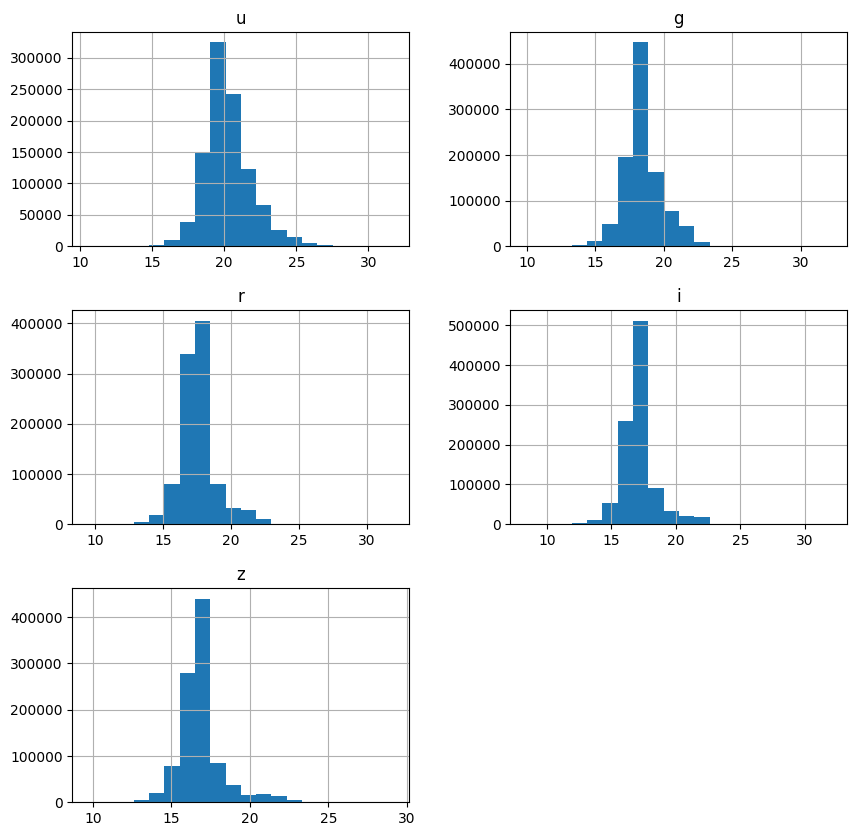

In [ ]:
X.hist(figsize=(10, 10), bins=20)
plt.show()

In [ ]:
# Based on the above plots choose a normalisation method by uncommenting the following:
#scaler = preprocessing.MinMaxScaler()
scaler = preprocessing.StandardScaler()
# Build a model for the scaler transform from the training data
scaler.fit(X_train)
# Apply that model to both the train and test data
X_train[:] = scaler.transform(X_train)
X_test[:] = scaler.transform(X_test)

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Look at our scaled data to check the effects of our code.

You should see all columns have either
- min = 0, max = 1.0 (min/max scaling)
- mean = 0, std = 1.0 (Standard Scaling)

In [ ]:
X_train.describe()

,u,g,r,i,z
count,7.999480e+05,7.999480e+05,7.999480e+05,7.999480e+05,7.999480e+05
mean,-2.754953e-16,-3.774320e-15,1.065803e-15,4.179187e-15,7.429953e-15
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00
min,-6.047343e+00,-6.174626e+00,-6.089321e+00,-6.567875e+00,-5.189413e+00
25%,-6.322493e-01,-5.616380e-01,-5.008887e-01,-4.891820e-01,-4.899854e-01
50%,-1.360332e-01,-1.163472e-01,-7.385334e-02,-7.178446e-02,-8.230364e-02
75%,5.073268e-01,4.334055e-01,2.575627e-01,2.455788e-01,2.544965e-01
max,7.193138e+00,9.911381e+00,1.087757e+01,1.123562e+01,8.959665e+00


## Feature engineering

Previously we have used a data-drive approach to determining which features are useful for our task.
If we are using predomenantly linear models for our algorithms, then the correlation between each feature and the target should be a reasonable indicator of the usefulness of that  feature.
By observing the correlation between features, we can also look for redundant data, which is what happens when we have highly correlated features.

For a full view of the correlation of all parameters we can use the pandas `.corr()` method to compute the correlation and then the seaborn `.heatmap()` method to display it.

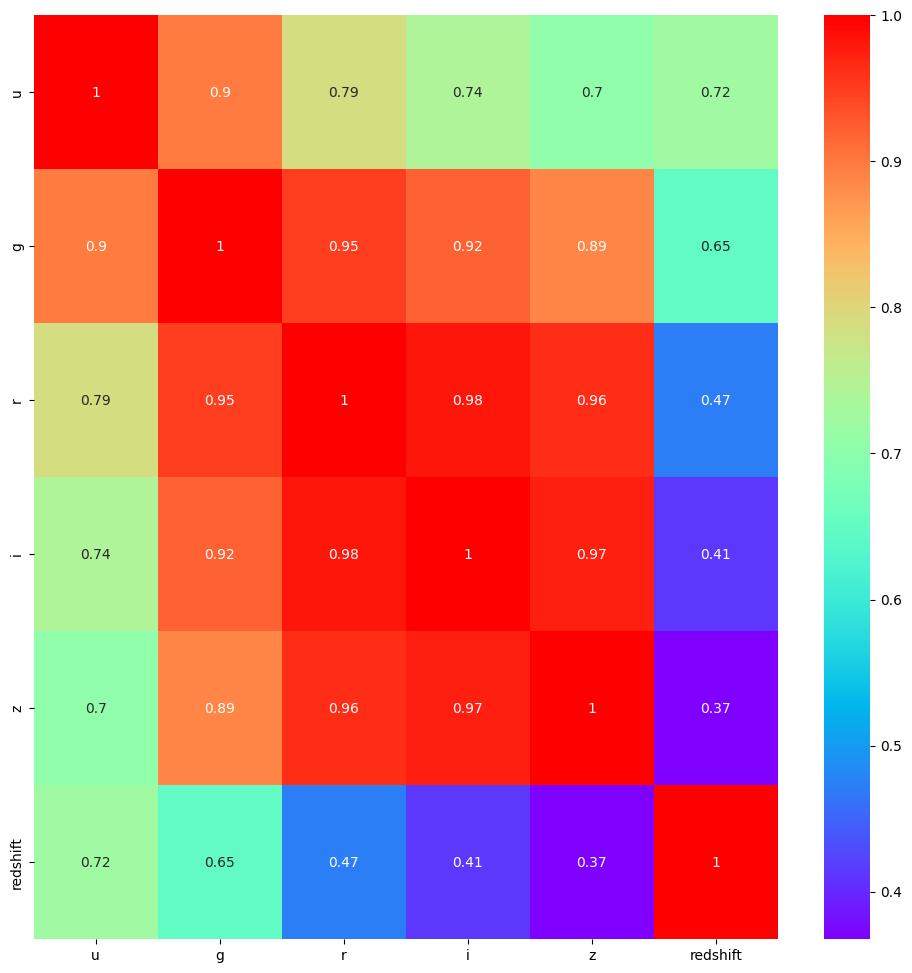

In [ ]:
# Compute the correlation between each of the numeric parameters as well as the
# target attribute
cor = pd.concat([X_train, y_train], axis=1).corr()

# use seaborn to do the plot
fig, ax = plt.subplots(1,1, figsize=(12,12))
sns.heatmap(cor, annot=True, cmap=plt.cm.rainbow, ax=ax)
plt.show()

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Is correlation the best way to judge the utility of a feature?

What assumptions are we making here?

How could we make different assumptions?

An alternative to a data-drive approach, is to take the advice of domain experts who can let us know what relationships should exist.
In this case, astronomers use the spectral shape (or "colours") of the galaxy classify galaxies into different types.
These colours are ratios of brightness levels, which correspond to linear combinations of magnitudes.

Let us add some additional features which are the pariwise differences between neighbouring bands.

Note that we need to compute the difference in the raw data first so that we are working with physically meaningful features.
We then scale this with our chosen scaler.

In [ ]:
# Create colours u-g g-r r-i and i-z
X_train['u-g'] = X_train['u'] - X_train['g']
X_train['g-r'] = X_train['g'] - X_train['r']
X_train['r-i'] = X_train['r'] - X_train['i']
X_train['i-z'] = X_train['i'] - X_train['z']

# And the same features for our test data
X_test['u-g'] = X_test['u'] - X_test['g']
X_test['g-r'] = X_test['g'] - X_test['r']
X_test['r-i'] = X_test['r'] - X_test['i']
X_test['i-z'] = X_test['i'] - X_test['z']

# We will also scales these features
c_scaler = preprocessing.StandardScaler()
c_scaler.fit(X_train[['u-g','g-r','r-i','i-z']])
X_train[['u-g','g-r','r-i','i-z']] = c_scaler.transform(X_train[['u-g','g-r','r-i','i-z']])
X_test[['u-g','g-r','r-i','i-z']] = c_scaler.transform(X_test[['u-g','g-r','r-i','i-z']])


Let us now make a correlation matrix of all the features that we have.

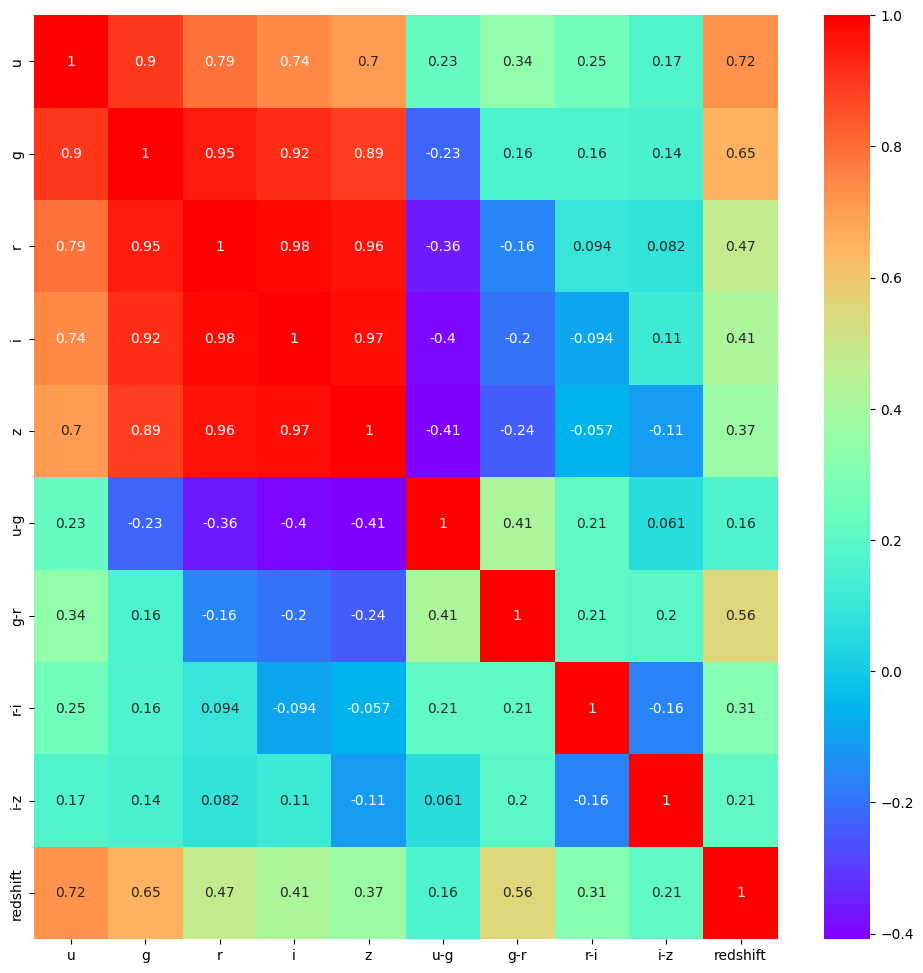

In [ ]:
# Compute the correlation between each of the numeric parameters as well as the
# target attribute
cor = pd.concat([X_train, y_train], axis=1).corr()

# use seaborn to do the plot
fig, ax = plt.subplots(1,1, figsize=(12,12))
sns.heatmap(cor, annot=True, cmap=plt.cm.rainbow, ax=ax)
plt.show()

Looking at the correlation map above we can see examples of:
- attribtes which have a correlation of ~1,
- attributes which are highly correlated with the redshift,
- attributes which have very low correlation with the redshift.

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

In each of the above cases, how does this inform our feature selection?

## Sampling data
The data set that we have contains 100,000 rows, which will take a **long time** to process for each of the cross validation splits and parameter combinations that we have in mind.
As such we are goint to make a subset of our data to work on while we select the model and parameters that will be used.
We will eventually train our best model on the entire data set.

In [ ]:
# subset the data to use just 10k rows
X_train_sub = X_train.sample(10_000, random_state=15)
y_train_sub = y_train[X_train_sub.index]

## KNN regressor

We can do our gridsearch as before however we can no longer use 'accuracy' as a metrics, since we don't have categorical data.

Instead we need to use a different scoring metric.

We will start with the root mean square error (RMSE).
Since the `GridSearchCV` will return the model with the *maximum* score, and lower values of RMSE are better we use a scorer which is just the negative of the RMSE: `neg_root_mean_squared_error`.

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Perform a gridsearch with cross validation using the RMSE metric for scoring.



In [ ]:
# Create a dictionary of all the parameters we'll be iterating over
parameters = {'weights': ('uniform','distance'), # this should be the different weighting schemes
              'n_neighbors':[1,5,13,17,43]} # this should be a list of the nearest neigbhours

# make a regressor object
estimator = KNeighborsRegressor()
# create a GridSearchCV object to do the training with cross validation
gscv = model_selection.GridSearchCV(estimator=estimator,
                                    param_grid=parameters,
                                    scoring='neg_root_mean_squared_error')
# now train our model
knn = gscv.fit(X_train_sub, y_train_sub)
knn_y_pred = knn.predict(X_test)
print(knn.best_params_, knn.best_score_)

{'n_neighbors': 13, 'weights': 'distance'} -0.031194681209475196


We have used cross validation which means that we can see the average and variance of the test score across the different validation splits. We can also view this for each of the parameter combinations.

In [ ]:
print("n_neighbors |  weights    |     -RMSE +/- std")
for i in range(len(knn.cv_results_['params'])):
  print(f"{knn.cv_results_['params'][i]['n_neighbors']:4d}   ", end='')
  print(f"{knn.cv_results_['params'][i]['weights']:>15s}     ", end='')
  print(f"{knn.cv_results_['mean_test_score'][i]:.5f}  +/- ", end='')
  print(f"{knn.cv_results_['std_test_score'][i]:.5f}")

n_neighbors |  weights    |     -RMSE +/- std
   1           uniform     -0.04100  +/- 0.00041
   1          distance     -0.04100  +/- 0.00041
   3           uniform     -0.03392  +/- 0.00079
   3          distance     -0.03388  +/- 0.00073
   5           uniform     -0.03213  +/- 0.00082
   5          distance     -0.03214  +/- 0.00082
   7           uniform     -0.03150  +/- 0.00070
   7          distance     -0.03145  +/- 0.00072
  13           uniform     -0.03138  +/- 0.00080
  13          distance     -0.03119  +/- 0.00082
  17           uniform     -0.03143  +/- 0.00072
  17          distance     -0.03120  +/- 0.00074
  21           uniform     -0.03159  +/- 0.00068
  21          distance     -0.03130  +/- 0.00069
  43           uniform     -0.03252  +/- 0.00069
  43          distance     -0.03207  +/- 0.00069


Is there a significant difference between the best and worst performing model in the above table?

How do you interpret your answer to the above?

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Retrain our KNN model using the best parameters and recompute the RMSE metric. Compare the new score to our expecations from above.

In [ ]:
# use the best n_neighbors and weights
best_knn = KNeighborsRegressor(n_neighbors=13, weights='distance')
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)
rmse = metrics.root_mean_squared_error(y_test, y_pred)
print(f'RMSE = {rmse}')

RMSE = 0.028391267341331253


We are going to be running more than one model so let us save a summary of the results into a dataframe.

In [ ]:
deltas = pd.DataFrame()
deltas['y-knn_y'] = y_test-knn_y_pred
deltas.describe()

,y-knn_y
count,199987.000000
mean,-0.000327
std,0.030963
min,-0.281239
25%,-0.014567
50%,-0.000270
75%,0.014207
max,0.282442


The above data frame doesn't give us a good feeling of how well the model predicts the data, so let's make a plot to visualise it.

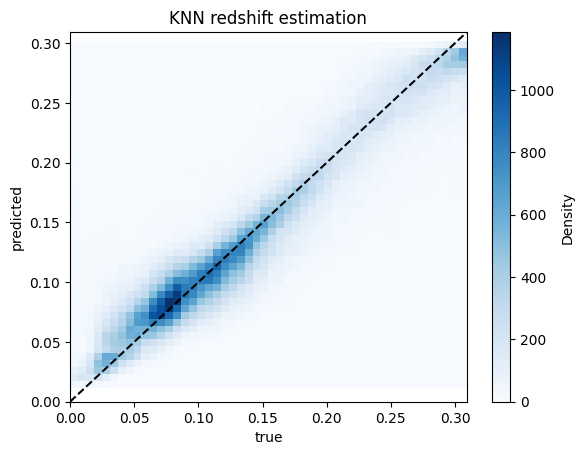

In [ ]:
mx = max(y_test.max(), knn_y_pred.max())
fig = plt.figure()
ax = fig.add_subplot(111)
# Use a 2D histogram to show density of points
plt.hist2d(y_test, knn_y_pred, bins=bins=[np.linspace(0,mx,50), np.linspace(0,mx,50)], cmap='Blues')
ax.plot([0,mx], [0, mx], 'k--')
ax.set_xlabel("true")
ax.set_ylabel("predicted")
ax.set_title("KNN redshift estimation")
ax.set_xlim(0,mx)
ax.set_ylim(0,mx)
plt.colorbar(label='Density')
plt.show()

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)
In the above plot, you should see that your ML model has done a fairly good job of estimating the redshift for the vast majority of galaxies.
The variance is less than 0.03 across a range of 0-0.3.

The prediction time of our KNN is rather long, and we will of course want to test other models in the hope that they perform better.

## Linear regression

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Fit a linear regression model to our data and predict some redshifts

In [ ]:
# no need for a grid search as there are no hyper-parameters to tune
lr = linear_model.LinearRegression()
lr.fit(X_train, y_train)
lr_y_pred = lr.predict(X_test)

For a little fun, let's have a look at the euqation of best fit that was generated by our model.

In [ ]:
print("redshift = ",end='')
for feature, coef in zip(X.columns, lr.coef_):
  print(f"{coef:+5.3f}*{feature} ", end='')
print(f"{lr.intercept_:+5.3f}")

redshift = +0.016*u +0.016*g +0.006*r +0.004*i +0.002*z +0.135


![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

What does it mean for a feature to have a high or low weight in the above equation?

If we were using un-scaled data would you have a different answer?

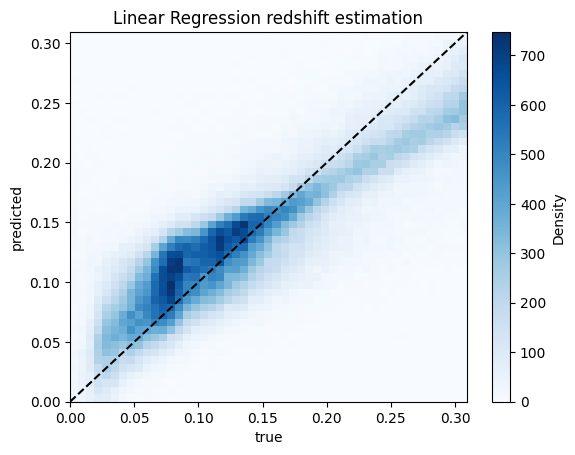

In [ ]:
#plot again but for the linear regression model
mx = y_test.max()
fig = plt.figure()
ax = fig.add_subplot(111)
plt.hist2d(y_test, lr_y_pred, bins=[np.linspace(0,mx,50), np.linspace(0,mx,50)], cmap='Blues')
ax.plot([0,mx], [0, mx], 'k--')
ax.set_xlabel("true")
ax.set_ylabel("predicted")
ax.set_title("Linear Regression redshift estimation")
ax.set_xlim(0,mx)
ax.set_ylim(0,mx)
plt.colorbar(label='Density')
plt.show()

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

What are some features of the above plot that are different from the KNN version of the plot?

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Add a new column to our `deltas` data frame for the linear regression results and compare them to the knn results.

In [ ]:
deltas['y-lr_y'] = y_test-lr_y_pred
deltas.describe()

,y-knn_y,y-lr_y
count,199987.000000,199987.000000
mean,-0.000327,0.000036
std,0.030963,0.044570
min,-0.281239,-0.911692
25%,-0.014567,-0.025124
50%,-0.000270,-0.000881
75%,0.014207,0.025078
max,0.282442,0.644327


## Regression trees

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Train a `DescisionTreeRegressor` with a range of `max_depth` and `min_samples_split`, using the `r2` scoring metric.

In [ ]:
# Create a dictionary of all the parameters we'll be iterating over
parameters = {'max_depth': [2, 3, 5, 7, 9, 11], #
              'min_samples_split':[50,150,500,1000]} #
# make a regressor object
estimator = DecisionTreeRegressor()
# create a GridSearchCV object to do the training with cross validation
gscv = model_selection.GridSearchCV(estimator=estimator,
                                    param_grid=parameters,
                                    scoring='neg_mean_squared_error')
# now train our model
dtr = gscv.fit(X_train_sub, y_train_sub)
dtr_y_pred = dtr.predict(X_test)
print(dtr.best_params_, dtr.best_score_)

{'max_depth': 11, 'min_samples_split': 50} -0.0011274762450133105


![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Use the best parameters from above to retrain on all the training data.

In [ ]:
best_dtr = DecisionTreeRegressor(max_depth=11,
                                 min_samples_split=50)
best_dtr.fit(X_train, y_train)
dtr_y_pred = best_dtr.predict(X_test)

In [ ]:
# save our differences again
deltas['y-dtr_y'] = y_test-dtr_y_pred
deltas.describe()

,y-knn_y,y-lr_y,y-dtr_y
count,199987.000000,199987.000000,199987.000000
mean,-0.000327,0.000036,-0.000032
std,0.030963,0.044570,0.029999
min,-0.281239,-0.911692,-0.278941
25%,-0.014567,-0.025124,-0.014224
50%,-0.000270,-0.000881,-0.000670
75%,0.014207,0.025078,0.013843
max,0.282442,0.644327,0.293434


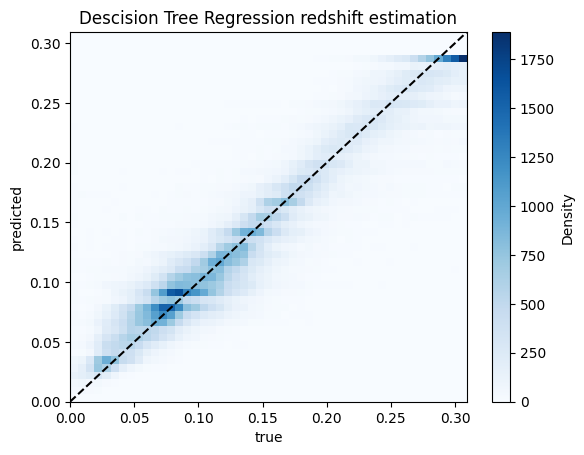

In [ ]:
# make another plot for the Decision Tree Regressor
mx = y_test.max()
fig = plt.figure()
ax = fig.add_subplot(111)
# ax.plot(y_test,dtr_y_pred, 'b.')
plt.hist2d(y_test, dtr_y_pred, bins=[np.linspace(0,mx,50), np.linspace(0,mx,50)], cmap='Blues')
ax.plot([0,mx], [0, mx], 'k--')
ax.set_xlabel("true")
ax.set_ylabel("predicted")
ax.set_title("Descision Tree Regression redshift estimation")
ax.set_xlim(0,mx)
ax.set_ylim(0,mx)
plt.colorbar(label='Density')
plt.show()

![Challenge](https://cdn.icon-icons.com/icons2/2110/PNG/64/challenge_icon_131034.png)

Based on the plotted outputs, the tablular data, and the scoring metrics, which of the three models is performing the best?

## Wrap up

Document your work in your notebook.
Pay careful attention to describing the actions that you took and the reasoning behind your choices.